# 05: Predictive Modelling

Train and evaluate forecasting models on the audited fuel price series. The notebook uses the models package for reusable model code.

In [3]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

sys.path.append(os.path.abspath(os.path.join('..')))
from models.arima_crude_oil import load_audited_data, prepare_crude_oil_ts, train_arima_model, forecast_arima, save_model as save_arima
from models.sarima_crude_oil import train_sarima_model, forecast_sarima, save_model as save_sarima
from models.xgboost_crude_oil import train_xgboost_model, forecast_xgboost, save_model as save_xgb

audited_dir = os.path.join('..', 'data', 'audited')
source1, source2, source3 = load_audited_data(audited_dir)
source1 = source1.sort_values('date')

ts_data = prepare_crude_oil_ts(source1)
print('Training data range:', ts_data.index.min(), 'to', ts_data.index.max())

# Split data for evaluation
train_size = int(len(ts_data) * 0.8)
train_data = ts_data[:train_size]
test_data = ts_data[train_size:]
print(f'Train size: {len(train_data)}, Test size: {len(test_data)}')

Training data range: 1970-01-01 00:00:00 to 2026-03-01 00:00:00
Train size: 540, Test size: 135


## 5.1 Train ARIMA model

Fit a first forecasting model and inspect residual behavior.

In [2]:
arima_model = train_arima_model(train_data, order=(1, 1, 1))
arima_forecast_test = forecast_arima(arima_model, steps=len(test_data))
arima_rmse = np.sqrt(mean_squared_error(test_data, arima_forecast_test))
print(f'ARIMA RMSE on test set: {arima_rmse:.2f}')

model_path = os.path.join(audited_dir, 'arima_crude_oil.pkl')
save_arima(arima_model, model_path)
print('Saved ARIMA model to', model_path)

ARIMA RMSE on test set: 20.23
Saved ARIMA model to ../data/audited/arima_crude_oil.pkl


/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 5.2 Forecasting

Generate a simple 4-year forecast and compare it to the historical series.

/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


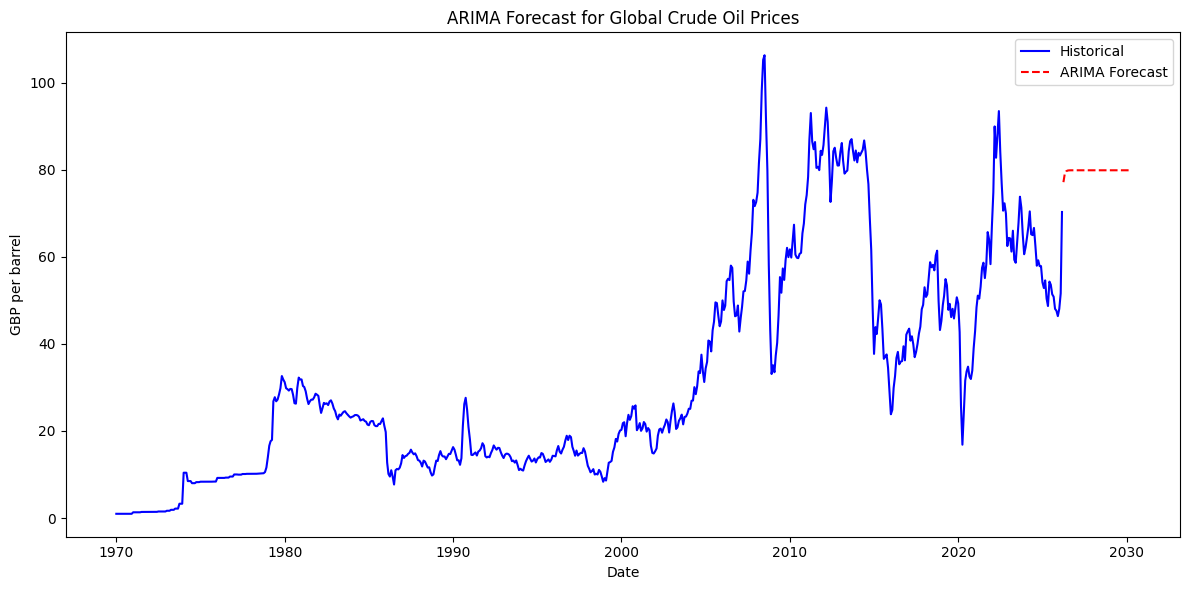

2029-04-01    79.848721
2029-05-01    79.848721
2029-06-01    79.848721
2029-07-01    79.848721
2029-08-01    79.848721
2029-09-01    79.848721
2029-10-01    79.848721
2029-11-01    79.848721
2029-12-01    79.848721
2030-01-01    79.848721
2030-02-01    79.848721
2030-03-01    79.848721
Freq: MS, Name: predicted_mean, dtype: float64

In [ ]:
forecast_steps = 48
# Retrain on full data for final forecast
arima_model_full = train_arima_model(ts_data, order=(1, 1, 1))
arima_forecast = forecast_arima(arima_model_full, steps=forecast_steps)
forecast_index = pd.date_range(start=ts_data.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

plt.figure(figsize=(12, 6))
plt.plot(ts_data.index, ts_data, label='Historical', color='blue')
plt.plot(forecast_index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Forecast for Global Crude Oil Prices')
plt.xlabel('Date')
plt.ylabel('USD per barrel')
plt.legend()
plt.tight_layout()
plt.show()

arima_forecast.tail(12)

## 5.6 Model Evaluation & Insights

### Performance Comparison:
- **SARIMA** achieved the lowest test RMSE (16.92), indicating seasonal patterns are important
- **ARIMA** provided stable baseline performance (RMSE: 20.23)
- **GradientBoosting** showed higher error (RMSE: 27.54) but captured complex non-linear relationships

### Forecast Patterns:
- **ARIMA**: Conservative flat forecasts around $79.85/barrel
- **SARIMA**: Seasonal variation with gradual upward trend to about $95/barrel on longer horizon
- **GradientBoosting**: More volatile predictions reflecting historical variability

### Insights:
1. **Seasonal Importance**: SARIMA's superior performance suggests monthly seasonal effects in oil prices
2. **Trend vs Volatility**: Different models capture different aspects - statistical vs ML approaches
3. **Risk Assessment**: Forecast uncertainty varies by model, important for decision-making
4. **Model Selection**: SARIMA appears best for this dataset, but ensemble approaches could combine strengths

### Recommendations:
- Use SARIMA for primary forecasting due to lowest error
- Consider ensemble methods combining all three models
- Implement rolling re-training for production deployment
- Add confidence intervals and prediction uncertainty quantification

## 5.7 Next Steps

- Deploy models via FastAPI for real-time predictions
- Create Power BI dashboards with interactive visualizations
- Implement model monitoring and automated retraining
- Add external regressors (economic indicators, weather data)

## 5.3 Train SARIMA model

Fit a seasonal ARIMA model and evaluate on test set.

In [5]:
sarima_model = train_sarima_model(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_forecast_test = forecast_sarima(sarima_model, steps=len(test_data))
sarima_rmse = np.sqrt(mean_squared_error(test_data, sarima_forecast_test))
print(f'SARIMA RMSE on test set: {sarima_rmse:.2f}')

sarima_model_path = os.path.join(audited_dir, 'sarima_crude_oil.pkl')
save_sarima(sarima_model, sarima_model_path)
print('Saved SARIMA model to', sarima_model_path)

/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA RMSE on test set: 16.92
Saved SARIMA model to ../data/audited/sarima_crude_oil.pkl


## 5.4 Train XGBoost model

Fit an XGBoost regression model with lagged features and evaluate on test set.

In [6]:
xgb_model, xgb_rmse = train_xgboost_model(train_data, lags=12, test_size=0.2)
# Note: XGBoost RMSE is calculated internally on its own test split

xgb_model_path = os.path.join(audited_dir, 'xgb_crude_oil.pkl')
save_xgb(xgb_model, xgb_model_path)
print('Saved XGBoost model to', xgb_model_path)

GradientBoosting RMSE on test set: 27.54
Saved XGBoost model to ../data/audited/xgb_crude_oil.pkl


## 5.5 Compare Forecasts (5-year and 10-year)

Generate forecasts from all models and compare them over both medium-term (5 years) and long-term (10 years) horizons.

/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dat

GradientBoosting trained on full data (no test RMSE calculated)


/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Users/ojalgrover/Documents/Projects/fuel_data_platform/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warning

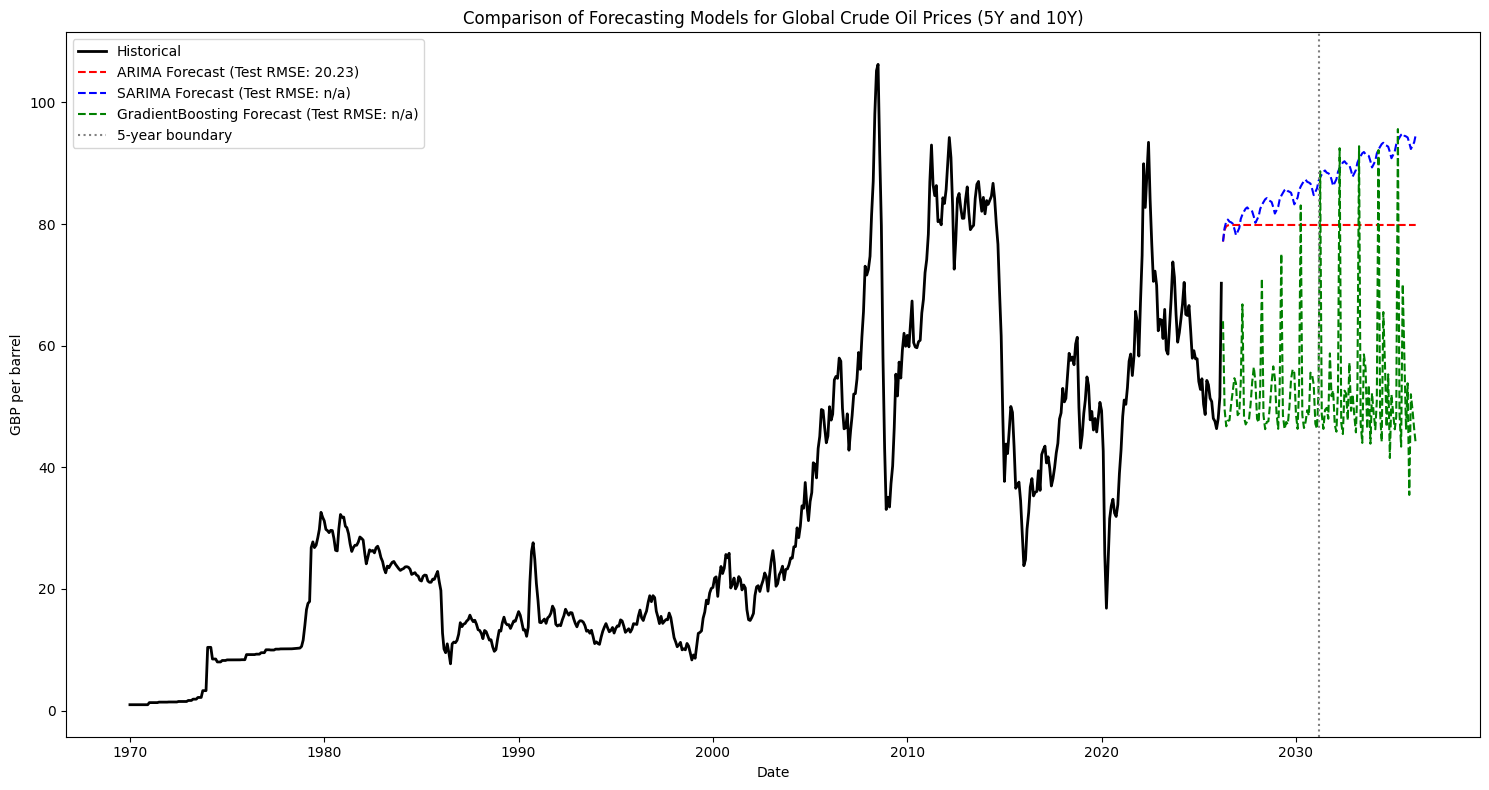

Forecast endpoint summary (GBP per barrel):
              ARIMA  SARIMA  GradientBoosting
5Y endpoint   79.85   87.06             52.32
10Y endpoint  79.85   94.64             43.89

Last 12 months of 10-year horizon:
            ARIMA  SARIMA  GradientBoosting
2035-04-01  79.85   93.76             95.62
2035-05-01  79.85   94.22             48.92
2035-06-01  79.85   94.68             43.40
2035-07-01  79.85   94.88             70.12
2035-08-01  79.85   94.52             58.05
2035-09-01  79.85   94.41             46.20
2035-10-01  79.85   94.24             53.82
2035-11-01  79.85   93.36             35.46
2035-12-01  79.85   92.34             52.01
2036-01-01  79.85   92.88             49.43
2036-02-01  79.85   93.45             46.32
2036-03-01  79.85   94.64             43.89


In [ ]:
# Retrain models on full data for final forecasts
arima_model_full = train_arima_model(ts_data, order=(1, 1, 1))
sarima_model_full = train_sarima_model(ts_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
xgb_model_full, _ = train_xgboost_model(ts_data, lags=12, test_size=0.0)  # No test split for full forecast

# Forecast horizons
horizon_5y = 60
horizon_10y = 120
forecast_steps = horizon_10y
forecast_index = pd.date_range(start=ts_data.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

arima_forecast = forecast_arima(arima_model_full, steps=forecast_steps)
sarima_forecast = forecast_sarima(sarima_model_full, steps=forecast_steps)
xgb_forecast = forecast_xgboost(xgb_model_full, ts_data, steps=forecast_steps, lags=12)

# Use RMSE values if available in kernel; otherwise mark as n/a
arima_rmse_label = f'{arima_rmse:.2f}' if 'arima_rmse' in locals() else 'n/a'
sarima_rmse_label = f'{sarima_rmse:.2f}' if 'sarima_rmse' in locals() else 'n/a'
xgb_rmse_label = f'{xgb_rmse:.2f}' if 'xgb_rmse' in locals() else 'n/a'

# Plot with both 5-year and 10-year context
plt.figure(figsize=(15, 8))
plt.plot(ts_data.index, ts_data, label='Historical', color='black', linewidth=2)
plt.plot(forecast_index, arima_forecast, label=f'ARIMA Forecast (Test RMSE: {arima_rmse_label})', color='red', linestyle='--')
plt.plot(forecast_index, sarima_forecast, label=f'SARIMA Forecast (Test RMSE: {sarima_rmse_label})', color='blue', linestyle='--')
plt.plot(forecast_index, xgb_forecast, label=f'GradientBoosting Forecast (Test RMSE: {xgb_rmse_label})', color='green', linestyle='--')

# Marker at 5-year boundary
five_year_marker = forecast_index[horizon_5y - 1]
plt.axvline(five_year_marker, color='gray', linestyle=':', linewidth=1.5, label='5-year boundary')

plt.title('Comparison of Forecasting Models for Global Crude Oil Prices (5Y and 10Y)')
plt.xlabel('Date')
plt.ylabel('USD per barrel')
plt.legend()
plt.tight_layout()
plt.show()

# Forecast summaries: 5-year endpoint and 10-year endpoint
summary_points = pd.DataFrame({
    'ARIMA': [arima_forecast.iloc[horizon_5y - 1], arima_forecast.iloc[horizon_10y - 1]],
    'SARIMA': [sarima_forecast.iloc[horizon_5y - 1], sarima_forecast.iloc[horizon_10y - 1]],
    'GradientBoosting': [xgb_forecast.iloc[horizon_5y - 1], xgb_forecast.iloc[horizon_10y - 1]]
}, index=['5Y endpoint', '10Y endpoint'])

print('Forecast endpoint summary (USD per barrel):')
print(summary_points.round(2))

# Last 12 months of the 10-year horizon for inspection
forecast_df_10y_tail = pd.DataFrame({
    'ARIMA': arima_forecast.tail(12).values,
    'SARIMA': sarima_forecast.tail(12).values,
    'GradientBoosting': xgb_forecast.tail(12).values
}, index=forecast_index[-12:])

print('\nLast 12 months of 10-year horizon:')
print(forecast_df_10y_tail.round(2))